In [ ]:
import zipfile
import os

# Path to your downloaded zip file
zip_path = "/content/en-hi.txt.zip"
extract_to = "/content/iit_bombay_en_hi"

# Create output folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✅ Files extracted to: {extract_to}")

In [ ]:
import pandas as pd

# Paths to your extracted text files
en_path = "/content/iit_bombay_en_hi/IITB.en-hi.en"
hi_path = "/content/iit_bombay_en_hi/IITB.en-hi.hi"

# Read files line by line
with open(en_path, "r", encoding="utf-8") as f_en:
    en_lines = f_en.read().strip().split("\n")

with open(hi_path, "r", encoding="utf-8") as f_hi:
    hi_lines = f_hi.read().strip().split("\n")

# Check both have same length
print(f"English lines: {len(en_lines)}, Hindi lines: {len(hi_lines)}")
min_len = min(len(en_lines), len(hi_lines))

# Truncate if mismatch
en_lines = en_lines[:min_len]
hi_lines = hi_lines[:min_len]

# Create DataFrame
df = pd.DataFrame({
    "src": en_lines,   # English sentence
    "mt": hi_lines,    # Machine-translated Hindi sentence
    "score": [1.0] * min_len   # Dummy quality score (you can update later)
})

# Save to CSV
df.to_csv("/content/en_hi_train.csv", index=False, encoding="utf-8")

print("✅ Saved dataset as en_hi_train.csv")
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/iit_bombay_en_hi/IITB.en-hi.en'

In [ ]:
# aug_mt_en_hi.py
import pandas as pd
import torch
import random
import math
from transformers import AutoTokenizer, AutoModelForMaskedLM
from typing import List
from tqdm import tqdm

# --- PERFORMANCE OPTIMIZATION ---
# Using 'base' model for faster processing. It's about 3x faster than 'large'.
# Change back to 'xlm-roberta-large' if you have sufficient compute and need higher quality.
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model.eval()
# Ensure the model is on the GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Using device: {device}")

# ----------------------
# Utilities
# ----------------------
def ids_to_text(ids: List[int]) -> str:
    return tokenizer.decode([i for i in ids if i not in tokenizer.all_special_ids], skip_special_tokens=True)

def safe_encode(text: str) -> List[int]:
    return tokenizer.encode(text, add_special_tokens=True)

def mask_index_positions(input_ids: torch.Tensor, mask_id: int):
    # returns indices of mask tokens in input_ids (1D tensor)
    return (input_ids == mask_id).nonzero(as_tuple=True)[0].tolist()

# ----------------------
# Compute informativeness (log P_cond - log P_uncond)
# ----------------------
def compute_informativeness(src: str, tgt_ids: List[int]) -> List[float]:
    """
    For each token index in tgt_ids, mask it and compute log_prob conditioned on src+tgt
    minus log_prob conditioned on tgt-only.
    Returns list of scores aligned with tgt_ids.
    """
    scores = []
    for i, tok in enumerate(tgt_ids):
        if tok in tokenizer.all_special_ids:
            scores.append(0.0)
            continue

        masked = tgt_ids.copy()
        masked[i] = tokenizer.mask_token_id
        masked_tgt_text = tokenizer.decode(masked, skip_special_tokens=False)

        # Case 1: conditioned on src + masked_tgt_text
        inputs = tokenizer(src, masked_tgt_text, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        mask_positions = mask_index_positions(inputs["input_ids"][0], tokenizer.mask_token_id)
        if not mask_positions:
            log_prob_cond = -100.0
        else:
            mp = mask_positions[0]
            log_probs = torch.log_softmax(logits[0, mp], dim=-1)
            log_prob_cond = float(log_probs[tok].cpu().item())

        # Case 2: conditioned on masked_tgt_text only
        inputs_uncond = tokenizer(masked_tgt_text, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits_uncond = model(**inputs_uncond).logits
        mask_positions_un = mask_index_positions(inputs_uncond["input_ids"][0], tokenizer.mask_token_id)
        if not mask_positions_un:
            log_prob_uncond = -100.0
        else:
            mpu = mask_positions_un[0]
            log_probs_un = torch.log_softmax(logits_uncond[0, mpu], dim=-1)
            log_prob_uncond = float(log_probs_un[tok].cpu().item())

        scores.append(log_prob_cond - log_prob_uncond)
    return scores

# ----------------------
# Augmentation methods
# ----------------------
def informed_deletion(tgt_ids: List[int], scores: List[float], drop_ratio=0.3, min_drop=1) -> (List[int], List[int]):
    n = len([i for i in tgt_ids if i not in tokenizer.all_special_ids])
    n_drop = max(min_drop, int(n * drop_ratio))
    weights = [max(0.0, s) if tok not in tokenizer.all_special_ids else 0.0 for s, tok in zip(scores, tgt_ids)]
    total = sum(weights)
    if total <= 0:
        candidates = [i for i, tok in enumerate(tgt_ids) if tok not in tokenizer.all_special_ids]
        drop_indices = random.sample(candidates, k=min(n_drop, len(candidates)))
    else:
        indices = [i for i, w in enumerate(weights) if w > 0]
        probs = [weights[i] for i in indices]
        drop_indices = []
        k = min(n_drop, len(indices))
        while len(drop_indices) < k:
            pick = random.choices(indices, weights=probs, k=1)[0]
            if pick not in drop_indices:
                drop_indices.append(pick)
    new_ids = [tok for i, tok in enumerate(tgt_ids) if i not in drop_indices]
    return new_ids, sorted(drop_indices)

def mlm_replace_single(tgt_ids: List[int], replace_ratio=0.2) -> (List[int], List[int]):
    candidate_positions = [i for i, tok in enumerate(tgt_ids) if tok not in tokenizer.all_special_ids]
    n_replace = max(1, int(len(candidate_positions) * replace_ratio))
    replace_positions = random.sample(candidate_positions, k=min(n_replace, len(candidate_positions)))
    new_ids = tgt_ids.copy()
    for pos in replace_positions:
        masked = new_ids.copy()
        masked[pos] = tokenizer.mask_token_id
        masked_text = tokenizer.decode(masked, skip_special_tokens=False)
        inputs = tokenizer(masked_text, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        mask_pos = mask_index_positions(inputs["input_ids"][0], tokenizer.mask_token_id)
        if not mask_pos:
            continue
        mp = mask_pos[0]
        topk_indices = torch.topk(logits[0, mp], k=5).indices.cpu().tolist()
        chosen = next((idx for idx in topk_indices if idx not in tokenizer.all_special_ids), None)
        if chosen is not None:
            new_ids[pos] = chosen
    return new_ids, sorted(replace_positions)

def random_deletion(tgt_ids: List[int], del_ratio=0.1) -> (List[int], List[int]):
    candidate_positions = [i for i, tok in enumerate(tgt_ids) if tok not in tokenizer.all_special_ids]
    n_del = max(1, int(len(candidate_positions) * del_ratio))
    del_positions = random.sample(candidate_positions, k=min(n_del, len(candidate_positions)))
    new_ids = [tok for i, tok in enumerate(tgt_ids) if i not in del_positions]
    return new_ids, sorted(del_positions)

def random_swap(tgt_ids: List[int], swap_ratio=0.1) -> (List[int], List[tuple]):
    """Swap pairs of tokens randomly. Returns new_ids and list of swapped index-pairs."""
    candidate_positions = [i for i, tok in enumerate(tgt_ids) if tok not in tokenizer.all_special_ids]

    # --- BUG FIX ---
    # If there are fewer than 2 tokens to swap, we can't perform a swap.
    if len(candidate_positions) < 2:
        return tgt_ids, []

    n_swaps = max(1, int(len(candidate_positions) * swap_ratio))
    new_ids = tgt_ids.copy()
    swaps = []
    # Ensure we don't try to perform more swaps than possible pairs
    for _ in range(min(n_swaps, len(candidate_positions) // 2)):
        i, j = random.sample(candidate_positions, 2)
        new_ids[i], new_ids[j] = new_ids[j], new_ids[i]
        swaps.append((i, j))
        # Remove swapped items from candidates to avoid re-swapping them
        candidate_positions.remove(i)
        candidate_positions.remove(j)
        if len(candidate_positions) < 2:
             break
    return new_ids, swaps

def span_drop(tgt_ids: List[int], span_ratio=0.15) -> (List[int], List[int]):
    """Drop one contiguous span whose length = ceil(span_ratio * len(tokens))."""
    candidate_positions = [i for i, tok in enumerate(tgt_ids) if tok not in tokenizer.all_special_ids]
    if not candidate_positions:
        return tgt_ids, []
    span_len = max(1, int(math.ceil(len(candidate_positions) * span_ratio)))
    if span_len >= len(candidate_positions):
        return [tok for i, tok in enumerate(tgt_ids) if i not in candidate_positions], sorted(candidate_positions)
    start_index = random.randint(0, len(candidate_positions) - span_len)
    span_indices = candidate_positions[start_index : start_index + span_len]
    new_ids = [tok for i, tok in enumerate(tgt_ids) if i not in span_indices]
    return new_ids, sorted(span_indices)


# ----------------------
# High-level augmentation pipeline
# ----------------------
def augment_row(src: str, mt: str, score: float, methods: List[str], params: dict):
    out_rows = []
    tgt_ids = safe_encode(mt)
    scores = None
    if "informed_deletion" in methods:
        scores = compute_informativeness(src, tgt_ids)

    for method in methods:
        try:
            if method == "informed_deletion":
                new_ids, dropped = informed_deletion(tgt_ids, scores, drop_ratio=params.get("drop_ratio", 0.3))
                if scores and sum(s > 0 for s in scores) > 0:
                    penalty = sum(scores[i] for i in dropped if i < len(scores)) / max(1e-8, sum(s for s in scores if s > 0))
                else:
                    penalty = 0.0
                new_score = score * (1 - max(0.0, penalty))
                out_rows.append({"src": src, "mt": ids_to_text(new_ids), "score": new_score, "method": method})
            elif method == "mlm_replace":
                new_ids, replaced = mlm_replace_single(tgt_ids, replace_ratio=params.get("replace_ratio", 0.2))
                new_score = score * (1 - 0.05 * len(replaced))
                out_rows.append({"src": src, "mt": ids_to_text(new_ids), "score": new_score, "method": method})
            elif method == "random_deletion":
                new_ids, dropped = random_deletion(tgt_ids, del_ratio=params.get("del_ratio", 0.1))
                new_score = score * (1 - 0.02 * len(dropped))
                out_rows.append({"src": src, "mt": ids_to_text(new_ids), "score": new_score, "method": method})
            elif method == "random_swap":
                new_ids, swaps = random_swap(tgt_ids, swap_ratio=params.get("swap_ratio", 0.1))
                new_score = score * (1 - 0.01 * len(swaps))
                out_rows.append({"src": src, "mt": ids_to_text(new_ids), "score": new_score, "method": method})
            elif method == "span_drop":
                new_ids, dropped = span_drop(tgt_ids, span_ratio=params.get("span_ratio", 0.15))
                new_score = score * (1 - 0.03 * len(dropped))
                out_rows.append({"src": src, "mt": ids_to_text(new_ids), "score": new_score, "method": method})
        except Exception as e:
            print(f"Error during augmentation for method '{method}' on src: '{src}'. Error: {e}")
            continue
    return out_rows

def augment_dataset(in_csv: str, out_csv: str, methods: List[str]=None, params: dict=None, max_rows=None):
    if methods is None:
        methods = ["informed_deletion", "mlm_replace", "random_deletion", "random_swap", "span_drop"]
    if params is None:
        params = {}

    try:
        df = pd.read_csv(in_csv)
    except FileNotFoundError:
        print(f"Error: Input file not found at {in_csv}")
        return

    if max_rows and max_rows > 0:
        df = df.head(max_rows)
        print(f"Processing a subset of {max_rows} rows.")

    new_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Augmenting dataset"):
        src, mt, score = str(row["src"]), str(row["mt"]), float(row.get("score", 1.0))
        augmented = augment_row(src, mt, score, methods, params)
        new_rows.append({"src": src, "mt": mt, "score": score, "method": "original"})
        new_rows.extend(augmented)

    out_df = pd.DataFrame(new_rows)
    out_df.to_csv(out_csv, index=False)
    print(f"\nSaved augmented data with {len(out_df)} rows to {out_csv}")


# ----------------------
# Example Usage
# ----------------------
if __name__ == "__main__":
    # Ensure this script is run in an environment with a GPU for reasonable speed.

    # Example parameters: tweak as you like
    params = {
        "drop_ratio": 0.3,    # for informed_deletion
        "replace_ratio": 0.2, # for mlm_replace
        "del_ratio": 0.1,     # for random_deletion
        "swap_ratio": 0.1,    # for random_swap
        "span_ratio": 0.15,   # for span_drop
    }

    # --- IMPORTANT ---
    # 1. Replace with the actual path to your input CSV file.
    # 2. Set 'max_rows' to a small number (e.g., 100) for a quick test run.
    # 3. Set 'max_rows' to a larger number (e.g., 50000) for a real run, or None to process all.
    #    Processing all 1.5M rows will still take a very long time.

    input_file = "/content/en_hi_train.csv" # <-- CHANGE THIS to your input file path
    output_file = "/content/en_hi_train_aug.csv" # <-- CHANGE THIS to your desired output file path

    augment_dataset(
        in_csv=input_file,
        out_csv=output_file,
        methods=None, # Use all methods
        params=params,
        max_rows=5000 # Process the first 5000 rows. Set to None to process all.
    )

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Using device: cuda
Processing a subset of 5000 rows.


Augmenting dataset: 100%|██████████| 5000/5000 [18:34<00:00,  4.49it/s]



Saved augmented data with 30000 rows to /content/en_hi_train_aug.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/en_hi_train_aug.csv")
print("Before cleaning:", len(df))

# Drop empty or whitespace-only translations
df = df[df['mt'].str.strip() != '']

# Drop any NaN values
df = df.dropna(subset=['src', 'mt', 'score'])

# Save cleaned version
df.to_csv("/content/en_hi_train_aug_clean.csv", index=False)
print("After cleaning:", len(df))


Before cleaning: 30000
After cleaning: 29027


<Figure size 800x500 with 0 Axes>

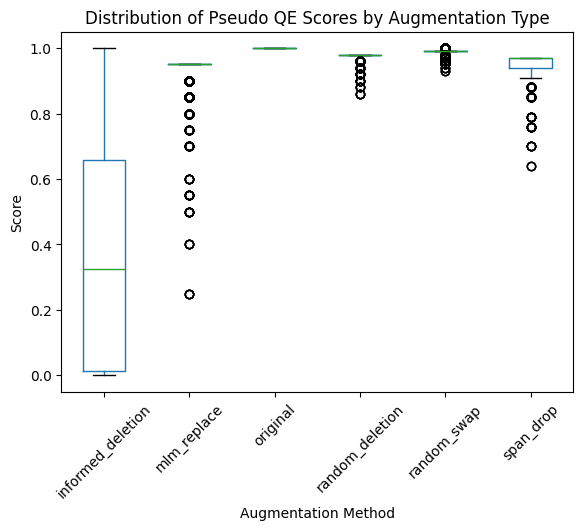

              method                                            src  \
0        mlm_replace                       View help for this game    
1  informed_deletion                                       _ Pause    
2  informed_deletion                           the six of diamonds    
3           original                               Remove the twos    
4        random_swap                            the four of spades    
5        random_swap  The default plugin layout for the top panel.    
6        mlm_replace                                          Name    
7        random_swap                                          Role    
8           original                                    Play “% s”    
9          span_drop                                           URI    

                                     mt     score  
0          इस खेल के लिए सहायता दिखायें  0.950000  
1                            ठहरें ( P)  0.860868  
2                             ईंट छक्का  1.000000  
3         

In [ ]:
import matplotlib.pyplot as plt

# Load and visualize
df_aug = pd.read_csv('/content/en_hi_train.csv')

# Plot score distribution per augmentation method
plt.figure(figsize=(8,5))
df_aug.boxplot(column="score", by="method", grid=False)
plt.title("Distribution of Pseudo QE Scores by Augmentation Type")
plt.suptitle("")
plt.xlabel("Augmentation Method")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# Show a few examples
print(df_aug.head(10)[["method", "src", "mt", "score"]])


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/en_hi_train_aug_clean.csv")

train, temp = train_test_split(df, test_size=0.2, random_state=42)
dev, test = train_test_split(temp, test_size=0.5, random_state=42)

train.to_csv("/content/en_hi_train.csv", index=False)
dev.to_csv("/content/en_hi_dev.csv", index=False)
test.to_csv("/content/en_hi_test.csv", index=False)

print(f"Train: {len(train)}, Dev: {len(dev)}, Test: {len(test)}")


Train: 23221, Dev: 2903, Test: 2903


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import mean_squared_error
import numpy as np
from tqdm import tqdm
import os

# ✅ Configuration
MODEL_NAME = "xlm-roberta-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 3
BATCH_SIZE = 8
LR = 2e-5

# ✅ Load Data
def load_data(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    return train_df, val_df, test_df

# ✅ Dataset class
class QEDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.src = df['src'].tolist()
        self.mt = df['mt'].tolist()
        self.scores = df['score'].tolist() if 'score' in df.columns else None
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.src[idx],
            self.mt[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        if self.scores is not None:
            item["labels"] = torch.tensor(self.scores[idx], dtype=torch.float)
        return item

# ✅ Model
class QERegressor(torch.nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained(model_name)
        self.dropout = torch.nn.Dropout(0.2)
        self.regressor = torch.nn.Linear(self.encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # CLS token
        x = self.dropout(pooled)
        preds = self.regressor(x).squeeze()
        loss = None
        if labels is not None:
            loss = torch.nn.MSELoss()(preds, labels)
        return preds, loss

# ✅ Training loop
def train_model(model, train_loader, val_loader, optimizer, scheduler):
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            preds, loss = model(**batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        print(f"Training Loss: {total_loss / len(train_loader):.4f}")

        # Validation
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                preds, _ = model(**batch)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(batch['labels'].cpu().numpy())
        mse = mean_squared_error(val_true, val_preds)
        rmse = mse ** 0.5

        print(f"Validation RMSE: {rmse:.4f}")

# ✅ Predict
def predict(model, test_loader, output_path):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            p, _ = model(**batch)
            preds.extend(p.cpu().numpy())
    pd.DataFrame({'predicted_score': preds}).to_csv(output_path, index=False)
    print(f"✅ Saved predictions to {output_path}")

# ✅ Main
def main():
    train_df, val_df, test_df = load_data(
        "/content/en_hi_train.csv",
        "/content/en_hi_dev.csv",
        "/content/en_hi_test.csv"
    )

    tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)

    train_dataset = QEDataset(train_df, tokenizer)
    val_dataset = QEDataset(val_df, tokenizer)
    test_dataset = QEDataset(test_df, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    model = QERegressor(MODEL_NAME).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    train_model(model, train_loader, val_loader, optimizer, scheduler)

    os.makedirs("/content/model_qe", exist_ok=True)
    torch.save(model.state_dict(), "/content/model_qe/en_hi_qe.pt")
    print("✅ Model saved!")

    predict(model, test_loader, "/content/model_qe/en_hi_predictions.csv")

if __name__ == "__main__":
    main()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

Training Loss: 0.0675


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Validation RMSE: 0.2324
✅ Model saved!


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


✅ Saved predictions to /content/model_qe/en_hi_predictions.csv


In [ ]:
import pandas as pd
preds = pd.read_csv("/content/model_qe/en_hi_predictions.csv")
print(preds.head())


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
# Import the QERegressor class defined in the training cell
from __main__ import QERegressor

# Base model you used during training — change if you used a different one
base_model_name = "xlm-roberta-base"

# Load tokenizer from base model
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# Initialize the QERegressor model architecture
model = QERegressor(base_model_name).to("cpu") # Load to CPU as map_location is cpu

# Load your fine-tuned weights
model.load_state_dict(torch.load("/content/model_qe/en_hi_qe.pt", map_location=torch.device("cpu")))

# Set model to evaluation mode
model.eval()

# Define prediction function
def predict_quality(src, mt):
    inputs = tokenizer(src, mt, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        # The QERegressor forward returns preds and loss (None during inference)
        preds, _ = model(**inputs)
        score = preds.item() # Get the single scalar prediction
    return score

print(predict_quality("I love apples.", "मुझे सेब पसंद हैं।"))

0.9197885990142822
